# Cell 1: Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cell 2: Upload Dataset

In [8]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


# Cell 3: Load Dataset

In [9]:
df = pd.read_csv('train.csv')

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

# Cell 4: Basic EDA

In [10]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nStatistics:")
print(df.describe())

Shape: (1460, 81)

Missing Values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

Statistics:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000    

# Cell 5: Handle Missing Values

In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

imputer = SimpleImputer(strategy='median')

df[num_cols] = imputer.fit_transform(df[num_cols])

# Cell 6: Encode Categorical Columns

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str)

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

# Cell 7: Remove Extreme Outliers

In [13]:
df = df[df['SalePrice'] < 500000]

# Cell 8: Feature Selection

In [14]:
correlation = df.corr()

top_features = correlation['SalePrice'].abs().sort_values(
    ascending=False
).head(11)

print(top_features)

SalePrice       1.000000
OverallQual     0.802424
GrLivArea       0.686872
GarageCars      0.654418
GarageArea      0.633607
ExterQual       0.627000
BsmtQual        0.612301
TotalBsmtSF     0.596771
1stFlrSF        0.589676
KitchenQual     0.571868
GarageFinish    0.563208
Name: SalePrice, dtype: float64


# Cell 9: Prepare Data

In [15]:
selected_features = top_features.index.tolist()

selected_features.remove('SalePrice')

X = df[selected_features]

y = df['SalePrice']

# Cell 10: Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cell 11: Train Regression Model

In [17]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# Cell 12: Make Predictions

In [18]:
predictions = model.predict(X_test)

# Cell 13: Evaluate Model

In [19]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 18011.744046621094
RMSE: 25553.75720890228
R2 Score: 0.8655057183785503


# Cell 14: Actual vs Predicted Plot

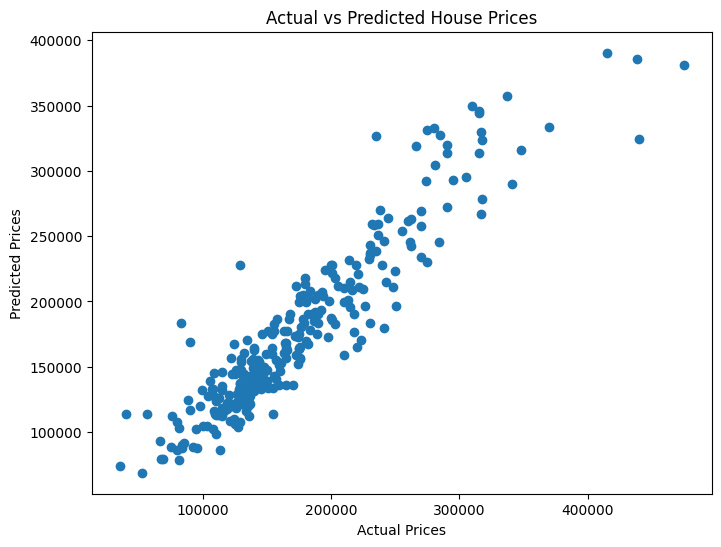

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

# Cell 15: Feature Importance

        Feature  Importance
0   OverallQual    0.593940
1     GrLivArea    0.149097
6   TotalBsmtSF    0.068962
3    GarageArea    0.050231
7      1stFlrSF    0.049309
5      BsmtQual    0.026828
2    GarageCars    0.025319
9  GarageFinish    0.014020
8   KitchenQual    0.011942
4     ExterQual    0.010351


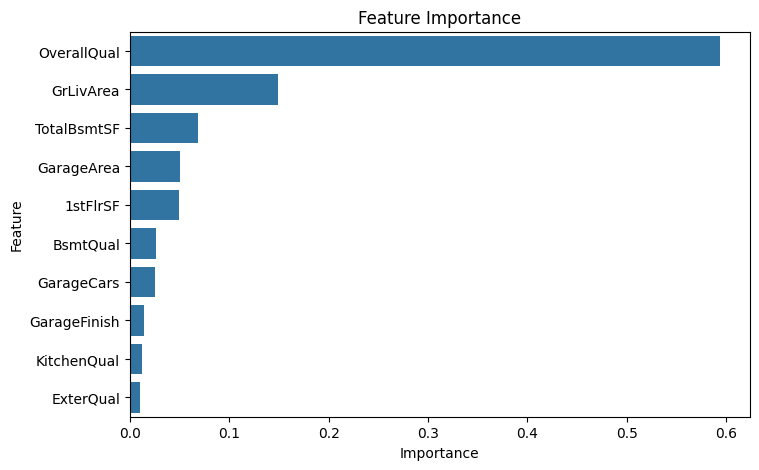

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()